# Bank Customer Churn - Exploratory Data Analysis (EDA)

**Objective:** Analyze the processed dataset to identify patterns, behaviors, and demographic factors that contribute to customer churn.
This analysis will generate the insights necessary to build our final Power BI Dashboard.

In [42]:
# 1. Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# removing warnings
import warnings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Overview

In [43]:
# 2. Loading the Processed Dataset

processed_data_path = r"J:\2.Estudos\Portfolio\bank_churn_project\data\processed\bank_churn_processed.csv"

df = pd.read_csv(processed_data_path)

### First 5 Rows (data preview)

In [44]:
df.head()

,CREDIT_SCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUM_OF_PRODUCTS,HAS_CR_CARD,IS_ACTIVE_MEMBER,ESTIMATED_SALARY,EXITED,HAS_CR_CARD_STATUS,IS_ACTIVE_MEMBER_STATUS,CHURN_STATUS,AGE_GROUP,BALANCE_SALARY_RATIO
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Yes,Active,Churned,41-50,0.00
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,No,Active,Retained,41-50,0.74
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Yes,Inactive,Churned,41-50,1.40
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,No,Inactive,Retained,31-40,0.00
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Yes,Active,Retained,41-50,1.59


### Descriptive Statistics

In [45]:
df.describe().round(2)

,CREDIT_SCORE,AGE,TENURE,BALANCE,NUM_OF_PRODUCTS,HAS_CR_CARD,IS_ACTIVE_MEMBER,ESTIMATED_SALARY,EXITED,BALANCE_SALARY_RATIO
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2,3.88
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4,108.34
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0,0.00
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0,0.00
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0,0.75
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0,1.51
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0,10614.66


### Checking any null values and inspect feature data types

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CREDIT_SCORE             10000 non-null  int64  
 1   GEOGRAPHY                10000 non-null  object 
 2   GENDER                   10000 non-null  object 
 3   AGE                      10000 non-null  int64  
 4   TENURE                   10000 non-null  int64  
 5   BALANCE                  10000 non-null  float64
 6   NUM_OF_PRODUCTS          10000 non-null  int64  
 7   HAS_CR_CARD              10000 non-null  int64  
 8   IS_ACTIVE_MEMBER         10000 non-null  int64  
 9   ESTIMATED_SALARY         10000 non-null  float64
 10  EXITED                   10000 non-null  int64  
 11  HAS_CR_CARD_STATUS       10000 non-null  object 
 12  IS_ACTIVE_MEMBER_STATUS  10000 non-null  object 
 13  CHURN_STATUS             10000 non-null  object 
 14  AGE_GROUP              

## 2. Univariate Analysis

### Churn Rate

In [47]:
# 3. Target Variable Analysis (Global Churn Rate)

global_churn_rate = df['EXITED'].mean()
print(f"Global Churn Rate: {global_churn_rate:.2%}")

Global Churn Rate: 20.37%


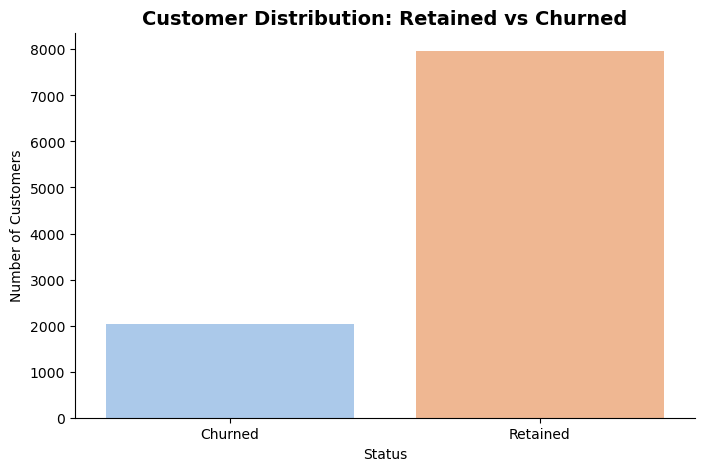

In [48]:
# 4. Visualizing the Churn Distribution

# using Seaborn for the graphics
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x= 'CHURN_STATUS', palette='pastel')

# Customizing the chart
plt.title("Customer Distribution: Retained vs Churned", fontsize=14, fontweight='bold')
plt.ylabel("Number of Customers")
plt.xlabel("Status")

# Removing the top and right spines
sns.despine()
plt.show()

**Population Size**

In [49]:
# 1. counting clients
country_totals = df['GEOGRAPHY'].value_counts().reset_index()
country_totals.columns = ['Country', 'Total Clients']

# 2. calculating the Market Share of each country
total_bank_clients = len(df) # to count the 10.000 rows
country_totals['% of Bank Base'] = (country_totals['Total Clients'] / total_bank_clients).map('{:.2%}'.format)

# 3. adding a row of "Grand Total" in the end to close
total_row = pd.DataFrame([{'Country': 'TOTAL', 'Total Clients': total_bank_clients, '% of Bank Base': '100.00%'}])
country_totals = pd.concat([country_totals, total_row], ignore_index=True)

print("--- Demographic Distribution ---")
country_totals

--- Demographic Distribution ---


,Country,Total Clients,% of Bank Base
0,France,5014,50.14%
1,Germany,2509,25.09%
2,Spain,2477,24.77%
3,TOTAL,10000,100.00%


## 3. Bivariate Analysis

In [50]:
# Checking Churn Possibilities

# Churn by Age

churn_by_age = df.groupby('AGE_GROUP')['EXITED'].mean()
churn_by_age = churn_by_age.sort_values(ascending=False).map('{:.2%}'.format)
churn_by_age

AGE_GROUP
51-60    56.04%
41-50    30.79%
60+      27.95%
31-40    10.88%
18-30     7.56%
Name: EXITED, dtype: object

In [51]:
# Churn by Country

churn_by_country = df.groupby('GEOGRAPHY')['EXITED'].mean()
churn_by_country = churn_by_country.sort_values(ascending=False).map('{:.2%}'.format)
churn_by_country

GEOGRAPHY
Germany    32.44%
Spain      16.67%
France     16.15%
Name: EXITED, dtype: object

In [52]:
# Churn with Credit Card and by Activity

churn_with_cr_card = df.groupby('HAS_CR_CARD_STATUS')['EXITED'].mean()
churn_with_cr_card = churn_with_cr_card.sort_values(ascending=False).map('{:.2%}'.format)

churn_by_activity = df.groupby('IS_ACTIVE_MEMBER_STATUS')['EXITED'].mean()
churn_by_activity = churn_by_activity.sort_values(ascending=False).map('{:.2%}'.format)

print("--- Churn with Credit Card ---")
print(churn_with_cr_card)
print("\n--- Churn by Activity ---")
print(churn_by_activity)

--- Churn with Credit Card ---
HAS_CR_CARD_STATUS
No     20.81%
Yes    20.18%
Name: EXITED, dtype: object

--- Churn by Activity ---
IS_ACTIVE_MEMBER_STATUS
Inactive    26.85%
Active      14.27%
Name: EXITED, dtype: object


**Key Insights**

* Clients between 51-60 years old have a critical churn rate of 56%.
* The operation in Germany has twice the churn rate (32%) compared to France and Spain.
* Inactive clients have double the churn rate (26%) compared to active members.

## 4. Multivariate Analysis

In [53]:
# churn by region and activity status 

churn_geo_activity = df.groupby(['GEOGRAPHY', 'IS_ACTIVE_MEMBER_STATUS'])['EXITED'].mean()
churn_geo_activity = churn_geo_activity.sort_values(ascending=False).map('{:.2%}'.format)
churn_geo_activity.unstack()

IS_ACTIVE_MEMBER_STATUS,Active,Inactive
GEOGRAPHY,,
France,11.50%,21.13%
Germany,23.72%,41.08%
Spain,10.75%,23.35%


In [54]:
# churn by age and region

churn_geo_age = df.groupby(['GEOGRAPHY', 'AGE_GROUP'])['EXITED'].mean()
churn_geo_age = churn_geo_age.sort_values(ascending=False).map('{:.2%}'.format)
churn_geo_age.unstack()

AGE_GROUP,18-30,31-40,41-50,51-60,60+
GEOGRAPHY,,,,,
France,5.20%,8.13%,25.52%,51.57%,24.82%
Germany,12.63%,18.86%,45.14%,70.04%,41.46%
Spain,7.94%,9.28%,24.37%,45.71%,21.71%


In [55]:
# Volumetric Validation

volumetric_validation_geo_age = df.groupby(['GEOGRAPHY', 'AGE_GROUP'])['EXITED'].count()
volumetric_validation_geo_age.unstack()

AGE_GROUP,18-30,31-40,41-50,51-60,60+
GEOGRAPHY,,,,,
France,866,2250,1242,382,274
Germany,372,997,740,277,123
Spain,403,1099,636,210,129


**Volumetric Validation:** 
> Before drawing conclusions from the high churn rates in specific clusters, we must verify the sample size. The critical segment (Germany, 51-60 years old) contains 277 clients. This is a statistically significant sample, confirming that the 70% churn rate is a validated business threat, not an anomaly caused by a low headcount.

**Key Insights 2**
* The Perfect Storm: Inactive customers in Germany represent the highest risk segment, with an alarming churn rate of 41.08% (more than double the global average).
* Structural & Regional Failure: The 51-60 age demographic is the primary driver of churn across all regions (>45%). However, this structural issue reaches a critical failure point in Germany, where an unprecedented 70.04% of clients in this age group abandon the bank.

## 5. Visualizing the Perfect Storm (heatmap)

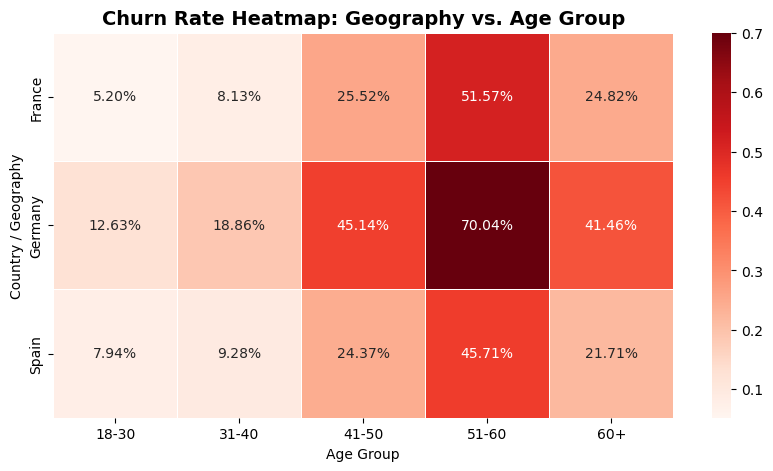

In [56]:
# formating dataframe
churn_matrix = df.groupby(['GEOGRAPHY', 'AGE_GROUP'])['EXITED'].mean().unstack()

# setting the graphic with seaborn
plt.figure(figsize=(10, 5))
sns.heatmap(churn_matrix,
    annot=True,          
    fmt='.2%',            
    cmap='Reds',         
    linewidths=0.5)

# customizing titles
plt.title("Churn Rate Heatmap: Geography vs. Age Group", fontsize=14, fontweight='bold')
plt.ylabel("Country / Geography")
plt.xlabel("Age Group")

plt.show()

## 6. Financial Impact Analysis

In [57]:
# Capital at Risk

capital_at_risk = df[df['EXITED'] == 1]['BALANCE'].sum()

print(f"Total Capital at Risk: ${capital_at_risk:,.2f}")

Total Capital at Risk: $185,588,094.63


In [58]:
# Average Balance by Country

avg_balance_country = df.groupby('GEOGRAPHY')['BALANCE'].mean().round(2)
print("\n--- Average Balance by Country ---")
print(avg_balance_country.apply(lambda x: f"${x:,.2f}"))


--- Average Balance by Country ---
GEOGRAPHY
France      $62,092.64
Germany    $119,730.12
Spain       $61,818.15
Name: BALANCE, dtype: object
